# IonBoost — build, run, and compare with Mora (2003)

This notebook drives the full workflow for the `IonBoost` solver:

1. write `input.in` from the parameter block below,
2. build the Fortran code with CMake,
3. run the executable,
4. load the CSV outputs,
5. reproduce the key results of P. Mora, *Plasma Expansion into a Vacuum*,
   [PRL **90**, 185002 (2003)](https://doi.org/10.1103/PhysRevLett.90.185002).

**Units** (with the default `n0hot = Thmax = 1`): position in initial Debye lengths
$\lambda_{D0}$, time in $\omega_{pi}^{-1}$, velocity in the ion-acoustic speed
$c_s$, densities in $n_0$, electric field in $E_0 = \sqrt{n_0 T_e/\varepsilon_0}$
(dimensionless value 1).

In [1]:
from io import StringIO
from pathlib import Path
import subprocess
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110

In [2]:
def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / 'README.md').exists() and (path / 'src').exists():
            return path
    raise FileNotFoundError('Could not locate the repository root from the current working directory.')


repo_root = find_repo_root()
src_dir = repo_root / 'src'
build_dir = repo_root / 'build'
viz_dir = repo_root / 'scripts' / 'viz'
viz_dir.mkdir(parents=True, exist_ok=True)
build_dir.mkdir(parents=True, exist_ok=True)

print(f'repo_root = {repo_root}')
print(f'build_dir = {build_dir}')
print(f'viz_dir   = {viz_dir}')

repo_root = /Users/42d/Mora
build_dir = /Users/42d/Mora/build
viz_dir   = /Users/42d/Mora/scripts/viz


## 1. Run parameters

To compare with the PRL (a semi-infinite plasma), keep `tmax < lmax / c_s`: the foil
behaves as semi-infinite until the rarefaction wave reflects off the rear side at
$t \simeq L/c_s$. Beyond that the run enters the thin-foil regime
(Mora, PRE **72**, 056401 (2005)).

In [3]:
params = dict(
    ncell=2450,     # ion cells
    nvacuum=400,    # vacuum-sheath cells beyond the ion front
    prog=0.996,     # mesh progression (<1: cells shrink towards the front)
    itmax=100000,   # max time steps
    tmax=50.0,      # final time [1/omega_pi]  -- Mora 2003 shows profiles at t=50
    iter0=20, iter1=10, iter2=5, iter3=5,   # Poisson-Boltzmann iteration counts
    dti=0.2,        # base time step
    n0hot=1.0,      # hot-electron reference density
    Thmax=1.0,      # hot-electron temperature
    lfini=True, lmax=60.0,   # finite foil of thickness lmax [lambda_D0]
    nb_cons=False, En_cons=False,   # forced off in single-species mode
    T_MeV=1.0, LSS=4.88, nLSS=20.0,
)


def fortran_logical(flag):
    return 'T' if flag else 'F'


input_text = (
    f"{params['ncell']} {params['nvacuum']} {params['prog']}   ! ncell nvacuum prog\n"
    f"{params['itmax']} {params['tmax']}       ! itmax  tmax\n"
    f"{params['iter0']} {params['iter1']} {params['iter2']} {params['iter3']}        ! iter0 iter1 iter2 iter3\n"
    f"{params['dti']}              ! dti\n"
    f"{params['n0hot']}            ! n0hot\n"
    f"{params['Thmax']}            ! Thmax\n"
    f"{fortran_logical(params['lfini'])}    {params['lmax']}   ! lfini lmax\n"
    f"{fortran_logical(params['nb_cons'])}  {fortran_logical(params['En_cons'])}   ! nb_cons En_cons\n"
    f"{params['T_MeV']}   {params['LSS']} {params['nLSS']}  ! T_MeV LSS nLSS\n"
)

(build_dir / 'input.in').write_text(input_text)
print(input_text)

2450 400 0.996   ! ncell nvacuum prog
100000 50.0       ! itmax  tmax
20 10 5 5        ! iter0 iter1 iter2 iter3
0.2              ! dti
1.0            ! n0hot
1.0            ! Thmax
T    60.0   ! lfini lmax
F  F   ! nb_cons En_cons
1.0   4.88 20.0  ! T_MeV LSS nLSS



## 2. Build and run

In [4]:
def sh(*cmd, cwd=None):
    proc = subprocess.run([str(c) for c in cmd], cwd=cwd, capture_output=True, text=True)
    tail = '\n'.join(proc.stdout.strip().splitlines()[-4:])
    if tail:
        print(tail)
    if proc.returncode != 0:
        print(proc.stderr)
        raise RuntimeError(f'command failed: {cmd}')
    return proc


sh('cmake', '-S', src_dir, '-B', build_dir, '-DCMAKE_BUILD_TYPE=Release')
sh('cmake', '--build', build_dir)

-- Check for working Fortran compiler: /opt/homebrew/bin/gfortran - skipped
-- Configuring done (1.3s)
-- Generating done (0.0s)
-- Build files have been written to: /Users/42d/Mora/build


[ 66%] Building Fortran object CMakeFiles/ionboost.dir/solver.f90.o
[ 83%] Building Fortran object CMakeFiles/ionboost.dir/main.f90.o
[100%] Linking Fortran executable ionboost
[100%] Built target ionboost


CompletedProcess(args=['cmake', '--build', '/Users/42d/Mora/build'], returncode=0, stdout='[ 16%] \x1bBuilding Fortran object CMakeFiles/ionboost.dir/types.f90.o\x1b\n[ 33%] \x1bBuilding Fortran object CMakeFiles/ionboost.dir/share.f90.o\x1b\n[ 50%] \x1bBuilding Fortran object CMakeFiles/ionboost.dir/param.f90.o\x1b\n[ 66%] \x1bBuilding Fortran object CMakeFiles/ionboost.dir/solver.f90.o\x1b\n[ 83%] \x1bBuilding Fortran object CMakeFiles/ionboost.dir/main.f90.o\x1b\n[100%] \x1b\x1bLinking Fortran executable ionboost\x1b\n[100%] Built target ionboost\n', stderr='')

In [5]:
t0 = time.time()
sh(build_dir / 'ionboost', cwd=build_dir)
print(f'run wall time: {time.time() - t0:.1f} s')

   50.000000000000000     
Final time =  50.0000
Number of iterations = 251
 time   50.000000000000000
run wall time: 0.6 s


## 3. Load the solver outputs

All four files are CSV with a single `#`-prefixed header line of column names.

In [6]:
def read_solver_table(path):
    path = Path(path)
    with open(path) as fh:
        header = fh.readline()
    if not header.startswith('#'):
        raise ValueError(f'expected a # header line in {path}')
    names = header[1:].split()
    frame = pd.read_csv(path, skiprows=1, header=None, names=names)
    return frame.apply(pd.to_numeric, errors='coerce')


profiles = read_solver_table(build_dir / 'profil.txt')
spectra = read_solver_table(build_dir / 'spectres.txt')
conservation = read_solver_table(build_dir / 'conservation.txt')
history = read_solver_table(build_dir / 'historique.txt')

for name, frame in [('profiles', profiles), ('spectra', spectra),
                    ('conservation', conservation), ('history', history)]:
    print(f'{name:12s} shape={frame.shape}  columns={list(frame.columns)[:6]}...')

t_final = float(history['time'].iloc[-1])
print(f'final time = {t_final}')

profiles     shape=(2851, 10)  columns=['x0', 'xt', 'v', 'phi', 'E', 'ni']...
spectra      shape=(2450, 4)  columns=['vmoy', 'Emoy', 'dndv', 'dndE']...
conservation shape=(251, 14)  columns=['time', 'nti', 'nthot', 'nte', 'n0hot', 'En_ion']...
history      shape=(251, 14)  columns=['time', 'xt(ivmax)', 'v(ivmax)', 'Energy_max', 'E(ivmax)', 'ne(ivmax)']...
final time = 50.0


## 4. Analytic results from Mora, PRL 90, 185002 (2003)

With $\tau = \omega_{pi} t / \sqrt{2e}$ (equation numbers are those of the paper):

- initial front field (Eq. 3): $E_{front,0} = \sqrt{2/e}\, E_0$
- self-similar field (Eq. 6): $E_{ss} = E_0 / \omega_{pi} t$
- field at the ion front (Eq. 9): $E_{front} \simeq 2 E_0 / \sqrt{2e + \omega_{pi}^2 t^2}$
- front velocity (Eq. 10): $v_{front} \simeq 2 c_s \ln\big(\tau + \sqrt{\tau^2+1}\big)$
- self-similar density: $n = n_0 \exp\!\big(-(x/c_s t + 1)\big)$
- front asymptotics (Eqs. 14, 17, 18, 20): $n_{e,front} \simeq 2 n_0/\omega_{pi}^2 t^2$,
  $n_{i,front} \simeq 4 n_0/\omega_{pi}^2 t^2$,
  $-\partial_x \ln n_e|_{front} \simeq 2/c_s t$,
  $-\partial_x \ln n_i|_{front} \simeq 1/2 c_s t$
- energy spectrum (Eq. 21): $dN/dE = \dfrac{n_0 c_s t}{\sqrt{2 E T_h}}\, e^{-\sqrt{2E/T_h}}$
- cutoff energy (Eq. 22): $E_{max} \simeq 2 T_h [\ln(2\tau)]^2$

These expressions assume `n0hot = 1` so that $\omega_{pi} = 1$ in code units.

In [7]:
Th = params['Thmax']
n0 = params['n0hot']
cs = np.sqrt(Th)
E0 = np.sqrt(n0 * Th)


def E_front_theory(t):
    return 2.0 * E0 / np.sqrt(2.0 * np.e + np.asarray(t) ** 2)


def v_front_theory(t):
    tau = np.asarray(t) / np.sqrt(2.0 * np.e)
    return 2.0 * cs * np.log(tau + np.sqrt(tau ** 2 + 1.0))


def E_ss(t):
    return np.sqrt(Th) / np.asarray(t)


def n_ss(x, t):
    xi = np.asarray(x) / (cs * t)
    return np.where(xi < -1.0, n0, n0 * np.exp(-(xi + 1.0)))


def dndE_theory(E, t):
    E = np.asarray(E)
    return n0 * cs * t / np.sqrt(2.0 * E * Th) * np.exp(-np.sqrt(2.0 * E / Th))

## 5. Density profile vs the self-similar solution (cf. Fig. 1)

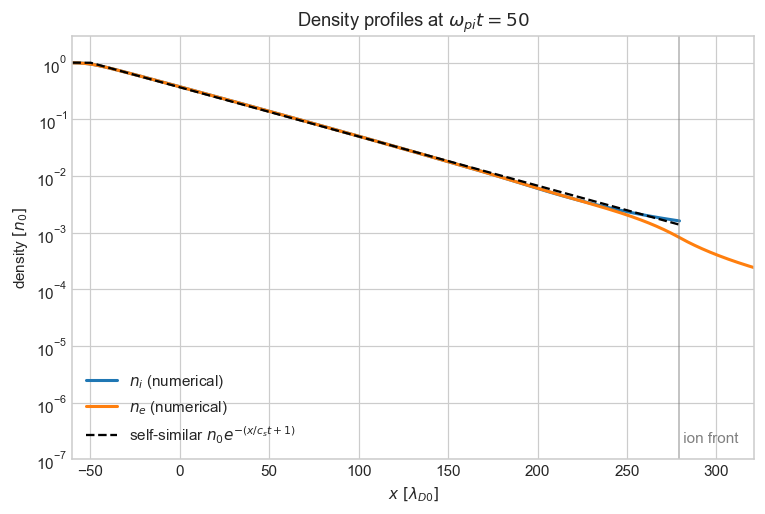

In [8]:
plasma = profiles[profiles['ni'] > 1e-10]
vacuum = profiles[profiles['ni'] <= 1e-10]
x_front = float(plasma['xt'].iloc[-1])

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(plasma['xt'], plasma['ni'], lw=2, label='$n_i$ (numerical)')
ax.semilogy(profiles['xt'], profiles['ne'], lw=2, label='$n_e$ (numerical)')
xg = np.linspace(-params['lmax'], x_front, 400)
ax.semilogy(xg, n_ss(xg, t_final), 'k--', lw=1.5,
            label='self-similar $n_0 e^{-(x/c_s t + 1)}$')
ax.axvline(x_front, color='gray', lw=1, alpha=0.6)
ax.text(x_front, 2e-7, ' ion front', color='gray')
ax.set_xlim(-params['lmax'], 1.15 * x_front)
ax.set_ylim(1e-7, 3 * n0)
ax.set_xlabel(r'$x\ [\lambda_{D0}]$')
ax.set_ylabel(r'density $[n_0]$')
ax.set_title(f'Density profiles at $\\omega_{{pi}} t = {t_final:.0f}$')
ax.legend()
fig.savefig(viz_dir / 'densities_profile.png', dpi=200, bbox_inches='tight')
plt.show()

## 6. Charge separation and front structure (cf. Figs. 1 and 5)

Fig. 1 of the paper: three layers — $+\sigma$ where the expansion starts
($x = -c_s t$), $+\sigma$ just left of the ion front, $-2\sigma$ in the electron
cloud beyond it. Fig. 5: front structure at the same time, no ion bump.

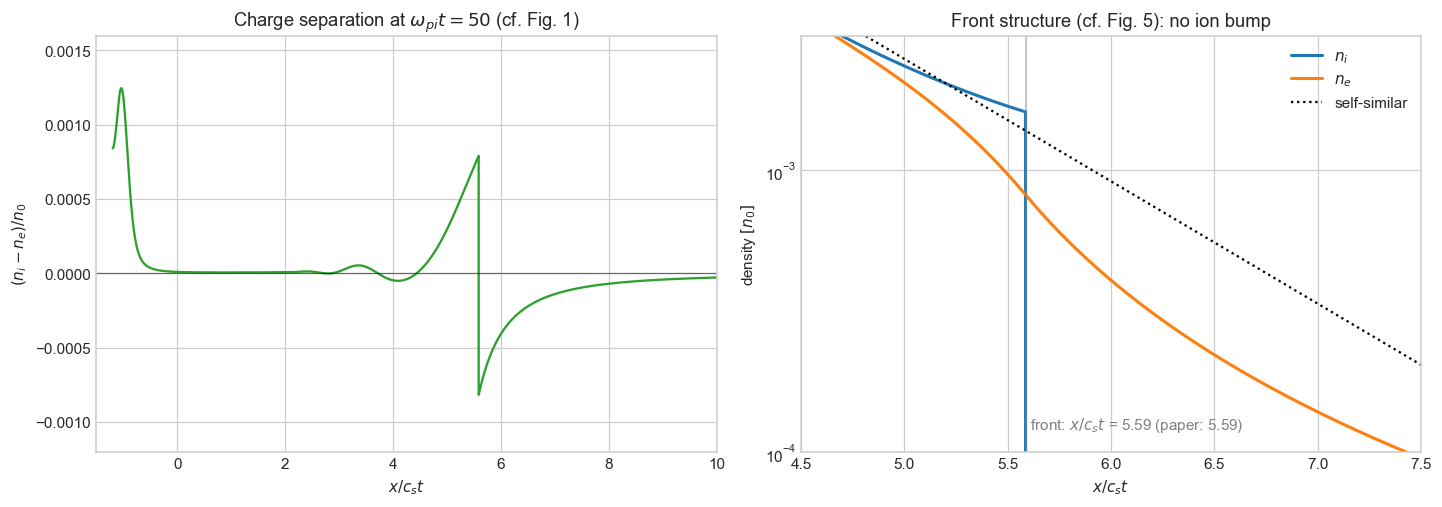

In [9]:
xi_prof = profiles['xt'] / (cs * t_final)
xi_front = x_front / (cs * t_final)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

ax = axes[0]
ax.plot(xi_prof, profiles['rho'], color='tab:green', lw=1.5)
ax.axhline(0.0, color='black', lw=0.8, alpha=0.5)
ax.set_xlim(-1.5, 10)
ax.set_ylim(-1.2e-3, 1.6e-3)
ax.set_xlabel(r'$x/c_s t$')
ax.set_ylabel(r'$(n_i - n_e)/n_0$')
ax.set_title(f'Charge separation at $\\omega_{{pi}} t = {t_final:.0f}$ (cf. Fig. 1)')

ax = axes[1]
sel = (xi_prof > 4.5) & (xi_prof < 7.5)
ax.semilogy(xi_prof[sel], profiles.loc[sel, 'ni'].clip(lower=1e-12),
            lw=2, label='$n_i$')
ax.semilogy(xi_prof[sel], profiles.loc[sel, 'ne'], lw=2, label='$n_e$')
xg = np.linspace(4.5, 7.5, 200) * cs * t_final
ax.semilogy(xg / (cs * t_final), n_ss(xg, t_final), 'k:', lw=1.5, label='self-similar')
ax.axvline(xi_front, color='gray', lw=1, alpha=0.6)
ax.text(xi_front, 1.2e-4, f' front: $x/c_s t$ = {xi_front:.2f} (paper: 5.59)',
        color='gray')
ax.set_xlim(4.5, 7.5)
ax.set_ylim(1e-4, 3e-3)
ax.set_xlabel(r'$x/c_s t$')
ax.set_ylabel(r'density $[n_0]$')
ax.set_title('Front structure (cf. Fig. 5): no ion bump')
ax.legend(loc='upper right')

fig.savefig(viz_dir / 'charge_separation.png', dpi=200, bbox_inches='tight')
plt.show()

## 7. Electric field profile and the vacuum sheath (cf. Fig. 2)

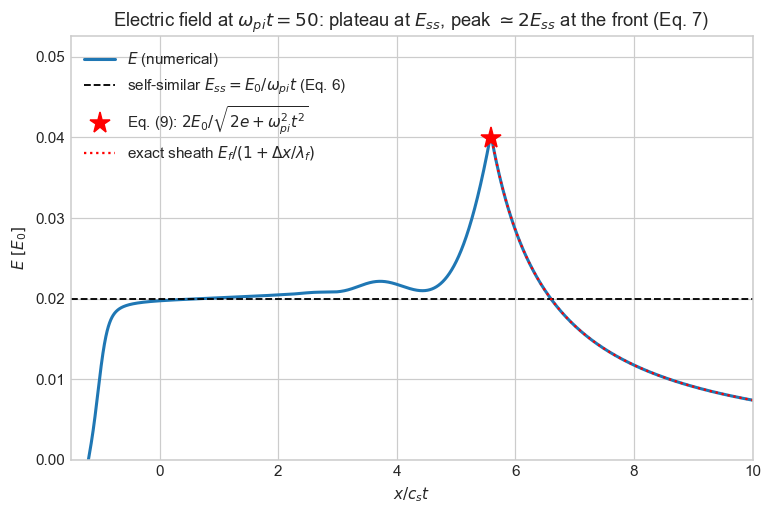

In [10]:
E_f = float(vacuum['E'].iloc[0])
ne_f = float(vacuum['ne'].iloc[0])
lam_sheath = np.sqrt(2.0 * Th / ne_f)   # exact Boltzmann-sheath decay length

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xi_prof, profiles['E'], lw=2, label='$E$ (numerical)')
ax.axhline(E_ss(t_final), color='k', ls='--', lw=1.2,
           label=r'self-similar $E_{ss} = E_0/\omega_{pi} t$ (Eq. 6)')
ax.plot([xi_front], [E_front_theory(t_final)], 'r*', ms=14,
        label=r'Eq. (9): $2E_0/\sqrt{2e+\omega_{pi}^2 t^2}$')
xs = np.linspace(x_front, 10 * cs * t_final, 200)
ax.plot(xs / (cs * t_final), E_f / (1.0 + (xs - x_front) / lam_sheath),
        'r:', lw=1.5, label=r'exact sheath $E_f/(1+\Delta x/\lambda_f)$')
ax.set_xlim(-1.5, 10)
ax.set_ylim(0, 1.3 * E_f)
ax.set_xlabel(r'$x/c_s t$')
ax.set_ylabel(r'$E\ [E_0]$')
ax.set_title(f'Electric field at $\\omega_{{pi}} t = {t_final:.0f}$: '
             'plateau at $E_{ss}$, peak $\\simeq 2E_{ss}$ at the front (Eq. 7)')
ax.legend()
fig.savefig(viz_dir / 'electric_field.png', dpi=200, bbox_inches='tight')
plt.show()

## 8. Front dynamics vs Mora Eqs. (9)-(10) (cf. Figs. 3-4)

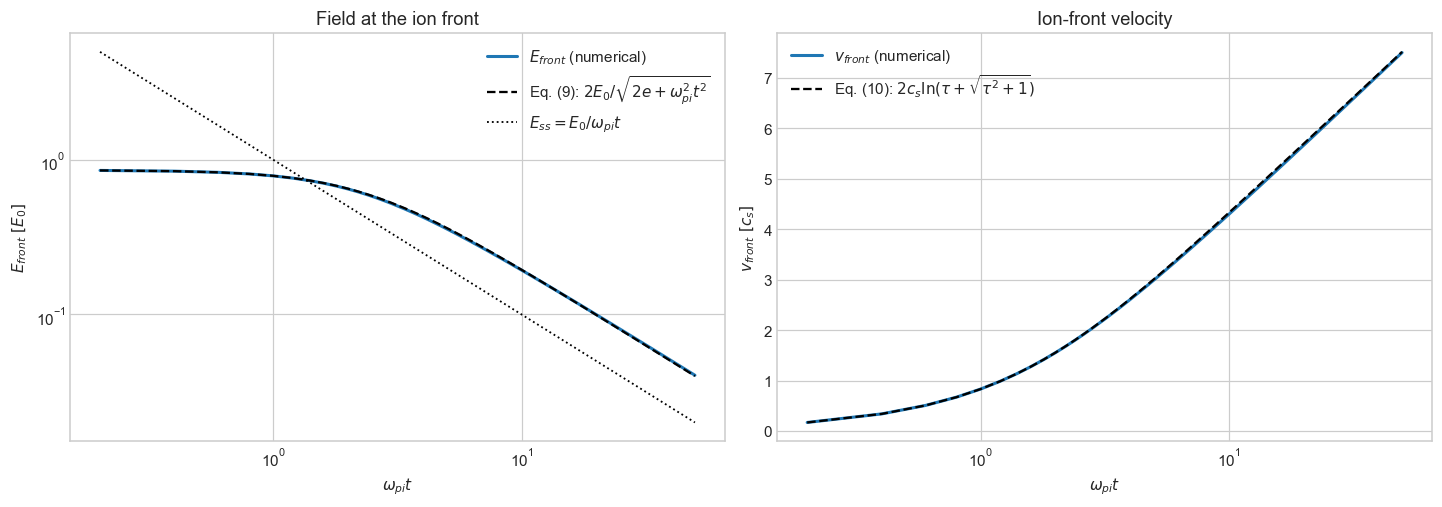

num/theory ratios:
  t=   5.00   E_front: 0.986   v_front: 0.994
  t=  10.00   E_front: 0.994   v_front: 0.993
  t=  20.00   E_front: 1.005   v_front: 0.995
  t=  50.00   E_front: 1.011   v_front: 0.998


In [11]:
hist = history[history['time'] > 0]
t = hist['time'].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

ax = axes[0]
ax.loglog(t, hist['E(ivmax)'], lw=2, label='$E_{front}$ (numerical)')
ax.loglog(t, E_front_theory(t), 'k--', lw=1.5,
          label=r'Eq. (9): $2E_0/\sqrt{2e+\omega_{pi}^2t^2}$')
ax.loglog(t, E_ss(t), 'k:', lw=1.2, label=r'$E_{ss} = E_0/\omega_{pi}t$')
ax.set_xlabel(r'$\omega_{pi} t$')
ax.set_ylabel(r'$E_{front}\ [E_0]$')
ax.set_title('Field at the ion front')
ax.legend()

ax = axes[1]
ax.semilogx(t, hist['v(ivmax)'], lw=2, label='$v_{front}$ (numerical)')
ax.semilogx(t, v_front_theory(t), 'k--', lw=1.5,
            label=r'Eq. (10): $2 c_s \ln(\tau+\sqrt{\tau^2+1})$')
ax.set_xlabel(r'$\omega_{pi} t$')
ax.set_ylabel(r'$v_{front}\ [c_s]$')
ax.set_title('Ion-front velocity')
ax.legend()

fig.savefig(viz_dir / 'front_dynamics.png', dpi=200, bbox_inches='tight')
plt.show()

print('num/theory ratios:')
for t_probe in (5, 10, 20, t_final):
    i = int(np.argmin(np.abs(t - t_probe)))
    rE = hist['E(ivmax)'].iloc[i] / E_front_theory(t[i])
    rv = hist['v(ivmax)'].iloc[i] / v_front_theory(t[i])
    print(f'  t={t[i]:7.2f}   E_front: {rE:.3f}   v_front: {rv:.3f}')

## 9. Ion energy spectrum vs Mora Eqs. (21)-(22) (cf. Fig. 7)

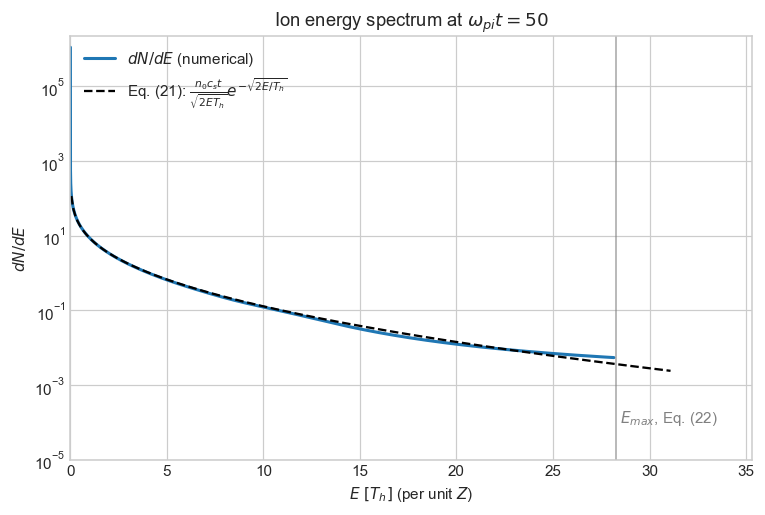

In [12]:
sp = spectra[(spectra['Emoy'] > 0) & (spectra['dndE'] > 0)]
E_max_th = 0.5 * v_front_theory(t_final) ** 2   # = Eq. (22) at large t

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(sp['Emoy'], sp['dndE'], lw=2, label='$dN/dE$ (numerical)')
Eg = np.linspace(0.05, 1.1 * E_max_th, 300)
ax.semilogy(Eg, dndE_theory(Eg, t_final), 'k--', lw=1.5,
            label=r'Eq. (21): $\frac{n_0 c_s t}{\sqrt{2ET_h}} e^{-\sqrt{2E/T_h}}$')
ax.axvline(E_max_th, color='gray', lw=1, alpha=0.7)
ax.text(E_max_th, 1e-4, r' $E_{max}$, Eq. (22)', color='gray')
ax.set_xlim(0, 1.25 * E_max_th)
ax.set_ylim(1e-5, 2 * float(sp['dndE'].max()))
ax.set_xlabel(r'$E\ [T_h]$ (per unit $Z$)')
ax.set_ylabel(r'$dN/dE$')
ax.set_title(f'Ion energy spectrum at $\\omega_{{pi}} t = {t_final:.0f}$')
ax.legend()
fig.savefig(viz_dir / 'energy_spectrum.png', dpi=200, bbox_inches='tight')
plt.show()

## 10. Front-structure asymptotics (cf. Fig. 6)

The paper's Eqs. (14), (17), (18), (20) give the large-time behavior of the
densities and their logarithmic gradients at the ion front. Here each quantity is
divided by its predicted asymptote, so all four curves should approach 1.

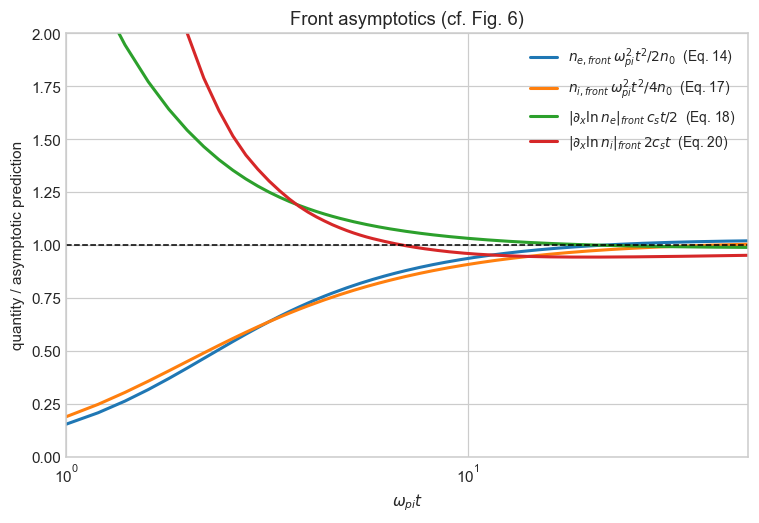

at t=50:
  x_front/cs t                = 5.587  (paper: 5.59 at t=50)
  ne_front * t^2/2            = 1.021  (Eq. 14 -> 1)
  ni_front * t^2/4            = 1.005  (Eq. 17 -> 1)
  grad-scale ne / (cs t/2)    = 0.990  (Eq. 18 -> 1)
  grad-scale ni / (2 cs t)    = 0.953  (Eq. 20 -> 1)
  0.5 v_front^2 = 28.15  vs Eq. (22): 28.25


In [13]:
ta = hist['time'].to_numpy()
scale_e = hist['lgrad_e_pressure'].to_numpy()    # = -1/(dln ne/dx) at the front
scale_i = hist['lgrad_i_pressure'].to_numpy()    # = -1/(dln ni/dx) at the front

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(ta, hist['ne(ivmax)'] * ta ** 2 / (2 * n0), lw=2,
            label=r'$n_{e,front}\, \omega_{pi}^2 t^2 / 2n_0$  (Eq. 14)')
ax.semilogx(ta, hist['ni(ivmax)'] * ta ** 2 / (4 * n0), lw=2,
            label=r'$n_{i,front}\, \omega_{pi}^2 t^2 / 4n_0$  (Eq. 17)')
ax.semilogx(ta, scale_e / (cs * ta / 2), lw=2,
            label=r'$|\partial_x \ln n_e|_{front}\, c_s t / 2$  (Eq. 18)')
ax.semilogx(ta, scale_i / (2 * cs * ta), lw=2,
            label=r'$|\partial_x \ln n_i|_{front}\, 2 c_s t$  (Eq. 20)')
ax.axhline(1.0, color='k', ls='--', lw=1)
ax.set_xlim(1, ta[-1])
ax.set_ylim(0, 2)
ax.set_xlabel(r'$\omega_{pi} t$')
ax.set_ylabel('quantity / asymptotic prediction')
ax.set_title('Front asymptotics (cf. Fig. 6)')
ax.legend(loc='upper right', fontsize=9)
fig.savefig(viz_dir / 'front_asymptotics.png', dpi=200, bbox_inches='tight')
plt.show()

i = -1
print(f'at t={ta[i]:.0f}:')
print(f'  x_front/cs t                = {hist["xt(ivmax)"].iloc[i]/(cs*ta[i]):.3f}  (paper: 5.59 at t=50)')
print(f'  ne_front * t^2/2            = {hist["ne(ivmax)"].iloc[i]*ta[i]**2/2:.3f}  (Eq. 14 -> 1)')
print(f'  ni_front * t^2/4            = {hist["ni(ivmax)"].iloc[i]*ta[i]**2/4:.3f}  (Eq. 17 -> 1)')
print(f'  grad-scale ne / (cs t/2)    = {scale_e[i]/(cs*ta[i]/2):.3f}  (Eq. 18 -> 1)')
print(f'  grad-scale ni / (2 cs t)    = {scale_i[i]/(2*cs*ta[i]):.3f}  (Eq. 20 -> 1)')
print(f'  0.5 v_front^2 = {0.5*hist["v(ivmax)"].iloc[i]**2:.2f}  vs Eq. (22): '
      f'{2*Th*np.log(2*ta[i]/np.sqrt(2*np.e))**2:.2f}')

## 11. Conservation checks

`En_balance = En_ion + En_elec - Whot` should stay constant (the electrons are an
isothermal reservoir; `Whot` tracks the energy they hand to ions and fields), and
the total ion number `nti` should be conserved.

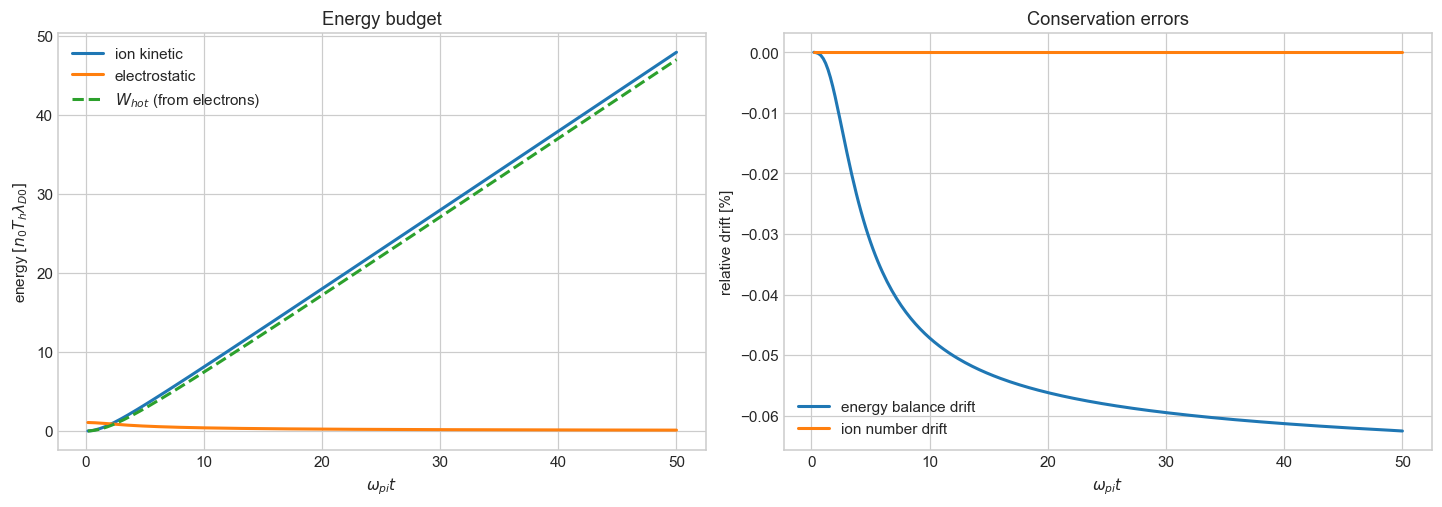

In [14]:
cons = conservation[conservation['time'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

ax = axes[0]
ax.plot(cons['time'], cons['En_ion'], lw=2, label='ion kinetic')
ax.plot(cons['time'], cons['En_elec'], lw=2, label='electrostatic')
ax.plot(cons['time'], cons['Whot'], lw=2, ls='--', label='$W_{hot}$ (from electrons)')
ax.set_xlabel(r'$\omega_{pi} t$')
ax.set_ylabel(r'energy $[n_0 T_h \lambda_{D0}]$')
ax.set_title('Energy budget')
ax.legend()

ax = axes[1]
scale = max(float(cons['En_ion'].iloc[-1]), 1e-12)
ax.plot(cons['time'],
        (cons['En_balance'] - cons['En_balance'].iloc[0]) / scale * 100,
        lw=2, label='energy balance drift')
ax.plot(cons['time'], (cons['nti'] / cons['nti'].iloc[0] - 1.0) * 100,
        lw=2, label='ion number drift')
ax.set_xlabel(r'$\omega_{pi} t$')
ax.set_ylabel('relative drift [%]')
ax.set_title('Conservation errors')
ax.legend()

fig.savefig(viz_dir / 'conservation.png', dpi=200, bbox_inches='tight')
plt.show()

## Notes

- The run stays in the semi-infinite regime of the PRL only while
  $t \lesssim L/c_s$ (`tmax < lmax` in code units). For longer times the foil
  fully rarefies and the results transition to the thin-foil regime of
  Mora, PRE **72**, 056401 (2005) — the spectrum steepens and the front field
  drops below Eq. (12).
- All figures are saved to `scripts/viz/`.